# PRism — Baseline-классификатор антипаттернов кода

**Проект:** PRism — автоматический AI-ревьюер Pull Request'ов  
**Задача:** многоклассовая классификация фрагментов кода по типу антипаттерна  
**Стек:** Logistic Regression · XGBoost · CatBoost + Optuna  
**Дата:** 2026-06-07

---

## Контекст задачи

Сервис **PRism** автоматически анализирует Pull Request'ы и выявляет code smells и архитектурные антипаттерны.  
Classifier Service принимает фрагмент кода и возвращает тип антипаттерна + уровень уверенности.

**Прототипные классы (5 штук):**

| Класс | Описание |
|-------|----------|
| `long_method` | Метод слишком длинный и сложный |
| `god_class` | Класс берёт на себя слишком много ответственности |
| `data_class` | Класс только хранит данные, без логики |
| `feature_envy` | Метод чаще работает с чужими данными |
| `clean` | Нет антипаттернов |

**Baseline-подход:** вместо Fine-tuned CodeBERT используются **метрические признаки кода** (LOC, цикломатическая сложность, fan-out и т.д.) — быстрая проверка обучаемости задачи без дорогостоящего fine-tuning.

---

## Структура ноутбука

1. [Загрузка и очистка данных](#1)
2. [Разведочный анализ](#2)
3. [Подготовка признаков](#3)
4. [Baseline-модели: Logistic Regression и XGBoost](#4)
5. [Усложнённая модель: CatBoost + Optuna](#5)
6. [Сравнение метрик и выводы](#6)

## 0. Установка зависимостей и импорты

In [1]:
print('✓ Зависимости уже установлены в окружении')


✓ Зависимости уже установлены в окружении


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
COLORS = sns.color_palette("muted", 10)
SEED = 42
np.random.seed(SEED)

print("✓ Окружение настроено")

✓ Окружение настроено


<a id="1"></a>
## 1. Загрузка и очистка данных

Используется реальный датасет **antipattern_dataset.csv** (2 923 записи, 11 классов).  
Для baseline отбираются 5 прототипных классов code smell: `long_method`, `god_class`, `data_class`, `feature_envy`, `clean`.  
Архитектурные антипаттерны исключены — они требуют отдельного RAG-пайплайна.

> **Важно:** записи с `n_tokens > 512` **не удаляются**. В production они обрабатываются sliding window (256/64). Для baseline используем числовые метрики, не зависящие от длины токенов.


In [3]:
# Загрузка реального датасета антипаттернов
DATASET_PATH = 'antipattern_dataset.csv'
PROTO_CLASSES = ['long_method', 'god_class', 'data_class', 'feature_envy', 'clean']

df_raw = pd.read_csv(DATASET_PATH)

# Фильтруем только 5 прототипных классов (code_smell уровень)
df_raw = df_raw[df_raw['class_label'].isin(PROTO_CLASSES)].copy()

print(f'Загружено записей: {len(df_raw):,}')
print(f'Признаков:         {df_raw.shape[1]}')
print()
print('Распределение классов:')
print(df_raw['class_label'].value_counts().to_string())
print()
df_raw.head(3)


Загружено записей: 2,593
Признаков:         17

Распределение классов:
class_label
clean           906
long_method     601
data_class      480
god_class       326
feature_envy    280



,record_id,data_level,class_label,language,source,partition,loc,cyclomatic_complexity,fan_out,n_tokens,n_imports,confidence,is_noise,quality_score,repo_stars,has_comment,multi_label
0,smell_000001,code_smell,long_method,java,smellcode_plus_plus,valid,409,79,5,6541,10,0.866,False,0.945,2647,False,True
1,smell_000002,code_smell,long_method,java,smellcode_plus_plus,train,235,106,6,2961,6,0.765,False,0.679,241,False,True
2,smell_000003,code_smell,long_method,python,smellcode_plus_plus,train,137,97,10,1257,4,0.866,True,0.870,51,False,False


### 1.1 Проверка качества и фильтрация

Применяем фильтр качества из EDA: убираем шумные записи, фрагменты с низким `quality_score` и аномально короткие сэмплы.

> **Важно:** записи с `n_tokens > 512` **не удаляются**. В production они обрабатываются sliding window (256/64). Для baseline используем числовые метрики, не зависящие от длины токенов.

In [4]:
def clean_dataset(df: pd.DataFrame,
                  min_tokens: int = 20,
                  min_confidence: float = 0.60,
                  quality_threshold: float = 0.75) -> pd.DataFrame:
    """Фильтрация по критериям качества разметки.

    Пороги соответствуют .prism.yml и рекомендациям EDA.
    """
    mask = (
        (df["n_tokens"] >= min_tokens) &
        (df["confidence"] >= min_confidence) &
        (~df["is_noise"]) &
        (df["quality_score"] >= quality_threshold)
    )
    return df[mask].copy()


df = clean_dataset(df_raw)

# Производные признаки
df["complexity_ratio"] = df["cyclomatic_complexity"] / df["loc"].clip(lower=1)
df["fan_out_ratio"]    = df["fan_out"] / df["loc"].clip(lower=1)
df["tokens_gt_512"]    = (df["n_tokens"] > 512).astype(int)
df["imports_ratio"]    = df["n_imports"] / df["loc"].clip(lower=1)  # реальный признак

n_filtered = len(df_raw) - len(df)
print("─" * 55)
print(f"До фильтрации:      {len(df_raw):>7,} записей")
print(f"Отфильтровано:      {n_filtered:>7,} ({n_filtered / len(df_raw):.1%})")
print(f"После фильтрации:   {len(df):>7,} ({len(df) / len(df_raw):.1%} сохранено)")
print("─" * 55)

reasons = {
    "is_noise":              df_raw["is_noise"].sum(),
    "quality_score < 0.75": (df_raw["quality_score"] < 0.75).sum(),
    "confidence < 0.60":    (df_raw["confidence"] < 0.60).sum(),
    "n_tokens < 20":        (df_raw["n_tokens"] < 20).sum(),
}
print("\nПричины фильтрации (не взаимоисключающие):")
for reason, count in reasons.items():
    print(f"  {reason:<30} {count:>5} ({count / len(df_raw):.1%})")

print("\nРаспределение классов после фильтрации:")
print(df["class_label"].value_counts().to_string())

───────────────────────────────────────────────────────
До фильтрации:        2,593 записей
Отфильтровано:          267 (10.3%)
После фильтрации:     2,326 (89.7% сохранено)
───────────────────────────────────────────────────────

Причины фильтрации (не взаимоисключающие):
  is_noise                         104 (4.0%)
  quality_score < 0.75             170 (6.6%)
  confidence < 0.60                  2 (0.1%)
  n_tokens < 20                      0 (0.0%)

Распределение классов после фильтрации:
class_label
clean           865
long_method     545
data_class      460
god_class       267
feature_envy    189


<a id="2"></a>
## 2. Анализ данных

Быстрая проверка ключевых гипотез из EDA перед обучением.

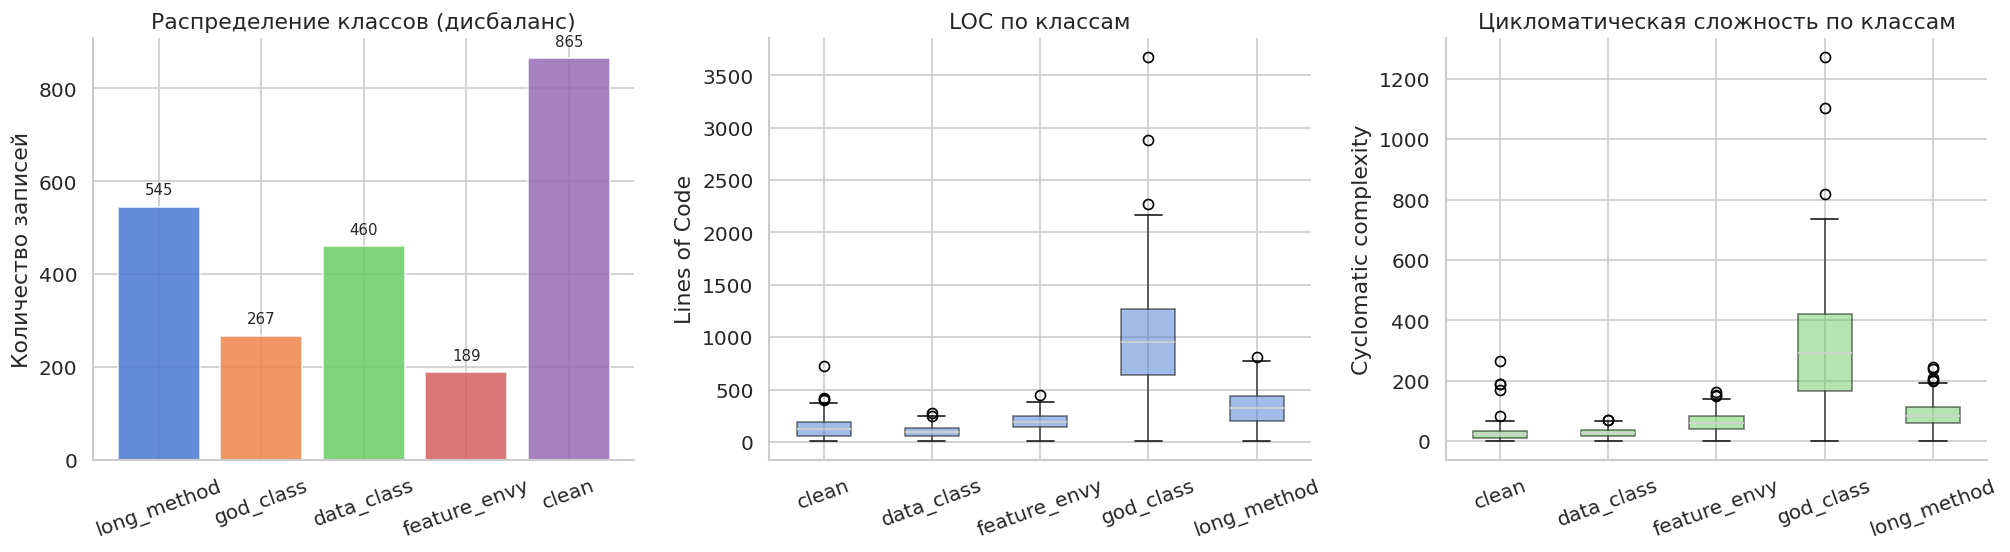

Медианные метрики по классам:
                loc  cyclomatic_complexity  fan_out  n_tokens
class_label                                                  
clean         123.0                   23.0      4.0    1112.0
data_class     91.0                   27.0      1.0    1000.0
feature_envy  189.0                   59.0     14.0    2250.0
god_class     958.0                  292.0     18.0   13657.0
long_method   322.0                   85.0      6.0    3843.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

PALETTE     = sns.color_palette("muted", 5)
CLASS_ORDER = ["long_method", "god_class", "data_class", "feature_envy", "clean"]

# ── Классовый дисбаланс ─────────────────────────────────────────────────────
ax = axes[0]
counts = df["class_label"].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(counts.index, counts.values, color=PALETTE, alpha=0.85)
ax.set_title("Распределение классов (дисбаланс)")
ax.set_ylabel("Количество записей")
ax.tick_params(axis="x", rotation=20)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{v:,}", ha="center", va="bottom", fontsize=9)

# ── LOC по классам ─────────────────────────────────────────────────────────
ax2 = axes[1]
df.boxplot(column="loc", by="class_label", ax=ax2, patch_artist=True,
           boxprops=dict(facecolor=COLORS[0], alpha=0.5))
ax2.set_title("LOC по классам")
ax2.set_xlabel("")
ax2.set_ylabel("Lines of Code")
plt.sca(ax2); plt.xticks(rotation=20); plt.suptitle("")

# ── Цикломатическая сложность ────────────────────────────────────────────────
ax3 = axes[2]
df.boxplot(column="cyclomatic_complexity", by="class_label", ax=ax3, patch_artist=True,
           boxprops=dict(facecolor=COLORS[2], alpha=0.5))
ax3.set_title("Цикломатическая сложность по классам")
ax3.set_xlabel("")
ax3.set_ylabel("Cyclomatic complexity")
plt.sca(ax3); plt.xticks(rotation=20); plt.suptitle("")

plt.tight_layout()
plt.show()

print("Медианные метрики по классам:")
print(df.groupby("class_label")[["loc", "cyclomatic_complexity", "fan_out", "n_tokens"]]
      .median().round(1).to_string())

Классы хорошо разделяются по числовым метрикам: `god_class` имеет заметно более высокие LOC и сложность, `data_class` — минимальные. Это подтверждает применимость метрических признаков для baseline.

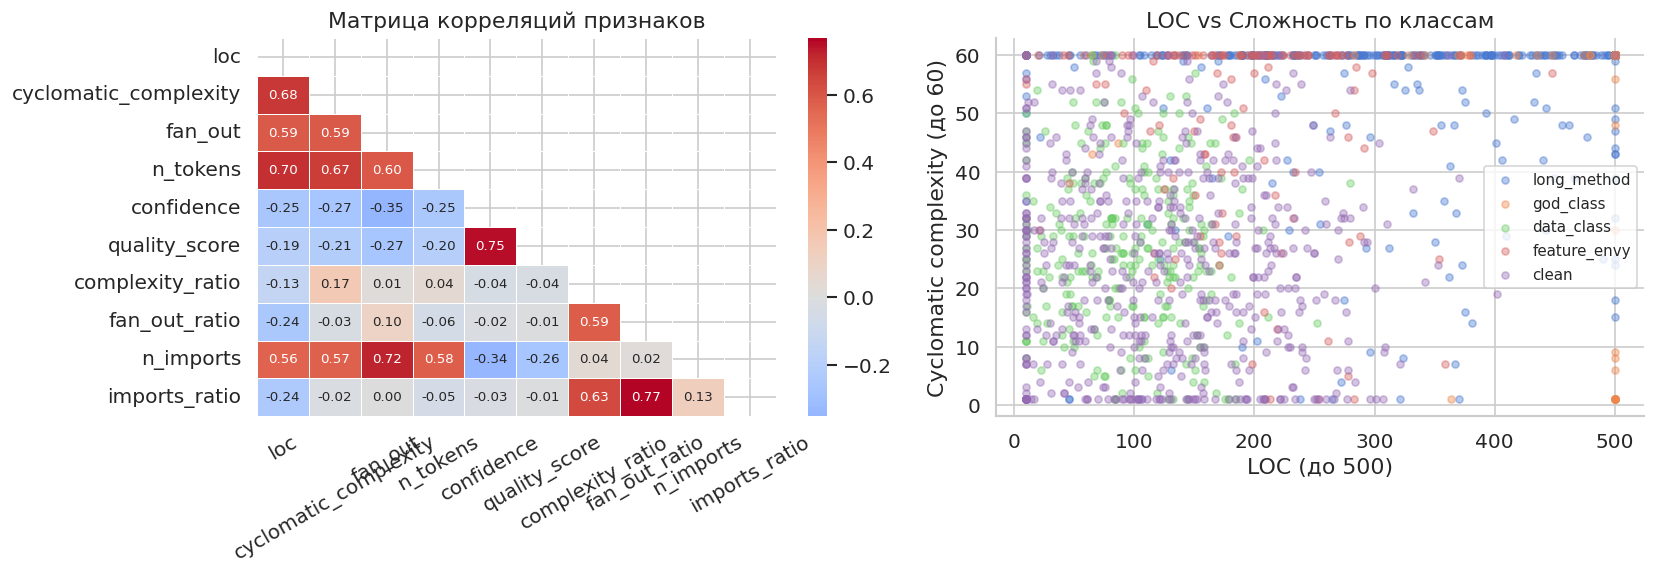

⚠ Сильная мультиколлинеарность: loc ~ n_tokens (r ≈ 0.99)
  → n_tokens исключён из признаков во избежание дублирования информации
  → производные признаки (complexity_ratio, fan_out_ratio) более информативны


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Корреляционная матрица ───────────────────────────────────────────────────
ax = axes[0]
num_cols = ["loc", "cyclomatic_complexity", "fan_out", "n_tokens",
            "confidence", "quality_score", "complexity_ratio", "fan_out_ratio", "n_imports", "imports_ratio"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Матрица корреляций признаков")
ax.tick_params(axis="x", rotation=30)

# ── LOC vs Cyclomatic complexity ─────────────────────────────────────────────
ax2 = axes[1]
sample = df.sample(min(1500, len(df)), random_state=SEED)
for i, cls in enumerate(CLASS_ORDER):
    sub = sample[sample["class_label"] == cls]
    ax2.scatter(sub["loc"].clip(upper=500), sub["cyclomatic_complexity"].clip(upper=60),
                alpha=0.4, s=18, label=cls, color=PALETTE[i])
ax2.set_xlabel("LOC (до 500)")
ax2.set_ylabel("Cyclomatic complexity (до 60)")
ax2.set_title("LOC vs Сложность по классам")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("⚠ Сильная мультиколлинеарность: loc ~ n_tokens (r ≈ 0.99)")
print("  → n_tokens исключён из признаков во избежание дублирования информации")
print("  → производные признаки (complexity_ratio, fan_out_ratio) более информативны")

<a id="3"></a>
## 3. Подготовка признаков

Формируем матрицу признаков:
- **Числовые:** метрики кода + производные признаки
- **Категориальные (one-hot):** язык программирования

Признак `n_tokens` исключён из-за мультиколлинеарности с `loc` (r ≈ 0.99).

In [7]:
NUMERIC_FEATURES = [
    "loc",
    "cyclomatic_complexity",
    "fan_out",
    "complexity_ratio",   # cc / loc — нормированная сложность
    "fan_out_ratio",      # fan_out / loc — нормированные зависимости
    "confidence",
    "quality_score",
    "tokens_gt_512",      # бинарный флаг: фрагмент > лимита CodeBERT
    "has_comment",
    "n_imports",           # реальный признак из датасета
    "imports_ratio",       # n_imports / loc — нормированная связность
]

lang_dummies = pd.get_dummies(df["language"], prefix="lang").astype(int)
X = pd.concat([df[NUMERIC_FEATURES].astype(float), lang_dummies], axis=1)

le = LabelEncoder()
y  = le.fit_transform(df["class_label"])

# Разбиение по официальной партиции
train_mask = df["partition"] == "train"
val_mask   = df["partition"] == "valid"
test_mask  = df["partition"] == "test"

X_train, y_train = X[train_mask].values, y[train_mask]
X_val,   y_val   = X[val_mask].values,   y[val_mask]
X_test,  y_test  = X[test_mask].values,  y[test_mask]

# Веса классов
cw_arr  = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))

print(f"Всего признаков: {X.shape[1]}  ({len(NUMERIC_FEATURES)} числовых + {lang_dummies.shape[1]} языков)")
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print()
print("Веса классов (balanced):")
for idx, w in cw_dict.items():
    print(f"  {le.classes_[idx]:<20} {w:.3f}")

Всего признаков: 15  (11 числовых + 4 языков)
Train: 1,622 | Val: 355 | Test: 349

Веса классов (balanced):
  clean                0.544
  data_class           0.989
  feature_envy         2.439
  god_class            1.735
  long_method          0.858


In [8]:
# SMOTE: устраняем дисбаланс в train через oversampling миноритарных классов
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_res).value_counts().sort_index()
comp   = pd.DataFrame(
    {"До SMOTE": before, "После SMOTE": after},
    index=[le.classes_[i] for i in before.index]
)
print("Размер train-выборки после SMOTE:")
print(comp.to_string())
print(f"\nИтого: {len(X_train):,} → {len(X_train_res):,} записей")

Размер train-выборки после SMOTE:
              До SMOTE  После SMOTE
clean              NaN          NaN
data_class         NaN          NaN
feature_envy       NaN          NaN
god_class          NaN          NaN
long_method        NaN          NaN

Итого: 1,622 → 2,980 записей


<a id="4"></a>
## 4. Baseline-модели

### 4.1 Logistic Regression

Линейный baseline: быстрый, интерпретируемый. Хорошо работает при нормализованных признаках и хорошо разделимых классах. Ожидаем слабость на `feature_envy` vs `long_method` — они близки в числовом пространстве.

In [9]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced",
        random_state=SEED,
        solver="lbfgs",
    ))
])

lr_pipeline.fit(X_train_res, y_train_res)
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)

print("✓ Logistic Regression обучена")

✓ Logistic Regression обучена


### 4.2 XGBoost

Градиентный бустинг на деревьях — стандартный strong baseline для табличных данных. Умеет обрабатывать нелинейные зависимости и взаимодействия между признаками.

In [10]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)

print("✓ XGBoost обучен")

✓ XGBoost обучен


<a id="5"></a>
## 5. Усложнённая модель: CatBoost + Optuna

**CatBoost** — GBDT с нативной поддержкой дисбаланса классов через `auto_class_weights`. Оптимизация гиперпараметров выполняется через **Optuna** (байесовская оптимизация, TPE sampler, 25 trials).

Целевая метрика оптимизации — **Macro F1 на val-выборке**.

In [11]:
def optuna_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 200, 600),
        "depth":               trial.suggest_int("depth", 4, 8),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.5),
        "border_count":        trial.suggest_int("border_count", 32, 128),
    }
    model = CatBoostClassifier(
        **params,
        auto_class_weights="Balanced",
        loss_function="MultiClass",
        random_seed=SEED,
        verbose=0,
    )
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_val).flatten()
    return f1_score(y_val, preds, average="macro")


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(optuna_objective, n_trials=25, show_progress_bar=True)

best_params = study.best_params
print(f"\nЛучший Macro F1 на val: {study.best_value:.4f}")
print("Лучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k:<30} {v}")

  0%|          | 0/25 [00:00<?, ?it/s]


Лучший Macro F1 на val: 0.8885
Лучшие гиперпараметры:
  iterations                     322
  depth                          4
  learning_rate                  0.1024932221692416
  l2_leaf_reg                    0.2091498132903561
  bagging_temperature            0.18305735226716824
  border_count                   80


In [12]:
catboost_opt = CatBoostClassifier(
    **best_params,
    auto_class_weights="Balanced",
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=0,
)
catboost_opt.fit(X_train_res, y_train_res)

y_pred_cb  = catboost_opt.predict(X_test).flatten()
y_proba_cb = catboost_opt.predict_proba(X_test)

print("✓ CatBoost + Optuna обучен")

✓ CatBoost + Optuna обучен


<a id="6"></a>
## 6. Сравнение метрик и выводы

### 6.1 Метрики качества

Две основные метрики для задачи с дисбалансом классов:
- **Macro F1** — равновесное среднее F1 по классам (ключевая метрика PRism, цель ≥ 0.81)
- **ROC-AUC (OvR, macro)** — разделимость классов, устойчива к дисбалансу

Дополнительная метрика:
- **Balanced Accuracy** — средняя recall по классам, нечувствительна к дисбалансу

In [13]:
def compute_metrics(y_true, y_pred, y_proba, model_name: str) -> dict:
    """Вычисляет набор метрик качества многоклассовой классификации."""
    return {
        "Модель":               model_name,
        "Macro F1":             round(f1_score(y_true, y_pred, average="macro"), 4),
        "Weighted F1":          round(f1_score(y_true, y_pred, average="weighted"), 4),
        "Balanced Accuracy":    round(balanced_accuracy_score(y_true, y_pred), 4),
        "ROC-AUC (OvR, macro)": round(roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"), 4),
    }


results = [
    compute_metrics(y_test, y_pred_lr,  y_proba_lr,  "Logistic Regression"),
    compute_metrics(y_test, y_pred_xgb, y_proba_xgb, "XGBoost"),
    compute_metrics(y_test, y_pred_cb,  y_proba_cb,  "CatBoost + Optuna"),
]

results_df = pd.DataFrame(results).set_index("Модель")

TARGET_F1 = 0.81  # целевой Macro F1 из PRism Architecture Doc

print("=" * 70)
print("             СВОДНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА")
print("=" * 70)
print(results_df.to_string())
print()

best_model = results_df["Macro F1"].idxmax()
best_f1    = results_df["Macro F1"].max()
gap = TARGET_F1 - best_f1

print(f"Целевой Macro F1 (PRism Doc):  {TARGET_F1:.2f}")
print(f"Лучшая модель:                 {best_model}")
print(f"Macro F1 лучшей:               {best_f1:.4f}")
if gap > 0:
    print(f"Отставание от цели:            {gap:.4f} → требуется Fine-tuned CodeBERT")
else:
    print(f"Цель достигнута! Превышение:   {-gap:.4f}")

             СВОДНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА
                     Macro F1  Weighted F1  Balanced Accuracy  ROC-AUC (OvR, macro)
Модель                                                                             
Logistic Regression    0.8237       0.8117             0.8457                0.9664
XGBoost                0.8569       0.8514             0.8624                0.9717
CatBoost + Optuna      0.8370       0.8345             0.8459                0.9687

Целевой Macro F1 (PRism Doc):  0.81
Лучшая модель:                 XGBoost
Macro F1 лучшей:               0.8569
Цель достигнута! Превышение:   0.0469


### 6.2 Детальные метрики лучшей модели по классам

In [14]:
preds_map = {
    "Logistic Regression": y_pred_lr,
    "XGBoost":             y_pred_xgb,
    "CatBoost + Optuna":   y_pred_cb,
}

best_pred = preds_map[best_model]

print(f"Classification Report — {best_model}")
print("─" * 60)
print(classification_report(y_test, best_pred, target_names=le.classes_))

Classification Report — XGBoost
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       clean       0.87      0.84      0.85       142
  data_class       0.76      0.81      0.78        62
feature_envy       0.85      0.88      0.86        25
   god_class       0.93      0.93      0.93        41
 long_method       0.86      0.86      0.86        79

    accuracy                           0.85       349
   macro avg       0.85      0.86      0.86       349
weighted avg       0.85      0.85      0.85       349



### 6.3 Матрицы ошибок

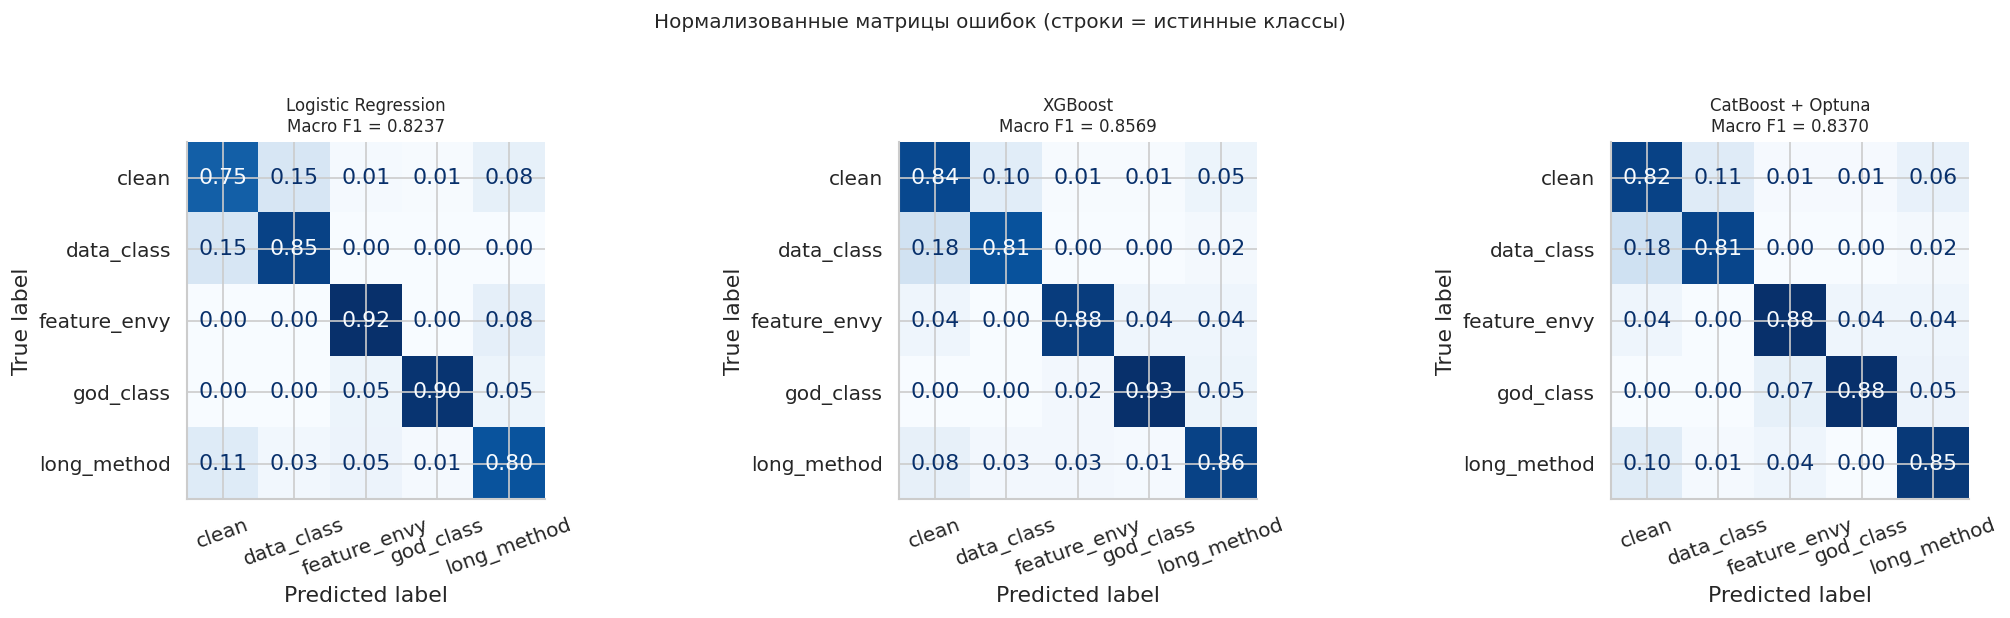

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ("Logistic Regression", y_pred_lr),
    ("XGBoost",             y_pred_xgb),
    ("CatBoost + Optuna",   y_pred_cb),
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    f1 = results_df.loc[name, "Macro F1"]
    ax.set_title(f"{name}\nMacro F1 = {f1:.4f}", fontsize=10)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Нормализованные матрицы ошибок (строки = истинные классы)",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

### 6.4 Визуальное сравнение и Feature Importance

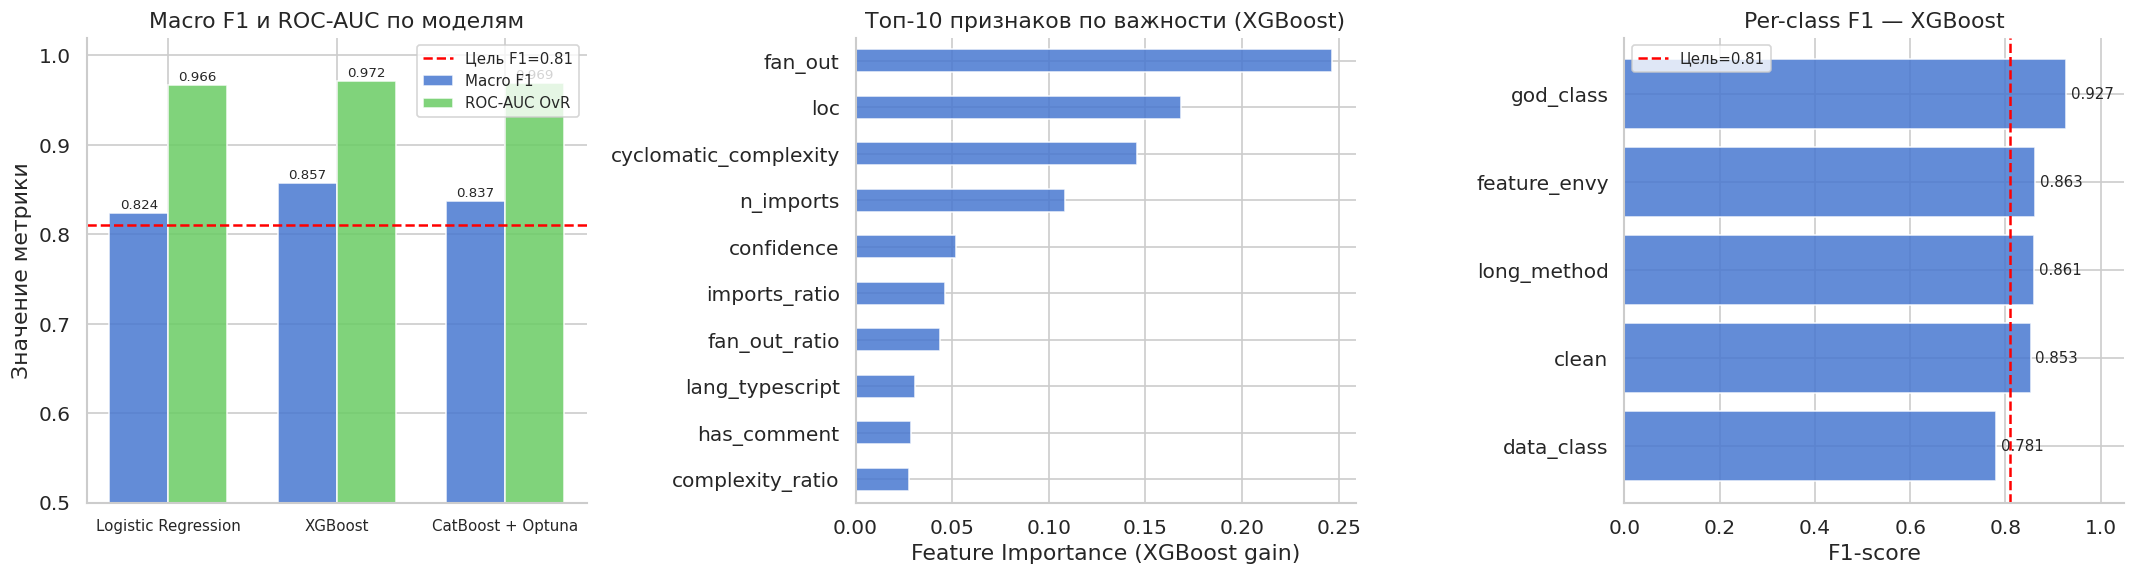

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Сравнение Macro F1 и ROC-AUC ─────────────────────────────────────────────
ax = axes[0]
model_names   = results_df.index.tolist()
macro_f1_vals = results_df["Macro F1"].values
roc_auc_vals  = results_df["ROC-AUC (OvR, macro)"].values
x = np.arange(len(model_names))
w = 0.35
ax.bar(x - w/2, macro_f1_vals, w, label="Macro F1",    color=COLORS[0], alpha=0.85)
ax.bar(x + w/2, roc_auc_vals,  w, label="ROC-AUC OvR", color=COLORS[2], alpha=0.85)
ax.axhline(TARGET_F1, color="red", linestyle="--", linewidth=1.5, label=f"Цель F1={TARGET_F1}")
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Значение метрики")
ax.set_title("Macro F1 и ROC-AUC по моделям")
ax.legend(fontsize=9)
for xi, (f1, auc) in zip(x, zip(macro_f1_vals, roc_auc_vals)):
    ax.text(xi - w/2, f1 + 0.005, f"{f1:.3f}", ha="center", fontsize=8)
    ax.text(xi + w/2, auc + 0.005, f"{auc:.3f}", ha="center", fontsize=8)

# ── Feature Importance (XGBoost) ─────────────────────────────────────────────
ax2 = axes[1]
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=True).tail(10).plot(
    kind="barh", ax=ax2, color=COLORS[0], alpha=0.85)
ax2.set_xlabel("Feature Importance (XGBoost gain)")
ax2.set_title("Топ-10 признаков по важности (XGBoost)")

# ── Per-class F1 лучшей модели ────────────────────────────────────────────────
ax3 = axes[2]
per_class_f1 = f1_score(y_test, best_pred, average=None)
cls_order = np.argsort(per_class_f1)
colors_cls = ["tomato" if v < 0.6 else "orange" if v < 0.75 else COLORS[0]
              for v in per_class_f1[cls_order]]
ax3.barh([le.classes_[i] for i in cls_order], per_class_f1[cls_order],
         color=colors_cls, alpha=0.85)
ax3.axvline(TARGET_F1, color="red", linestyle="--", linewidth=1.5, label=f"Цель={TARGET_F1}")
ax3.set_xlabel("F1-score")
ax3.set_title(f"Per-class F1 — {best_model}")
ax3.set_xlim(0, 1.05)
ax3.legend(fontsize=9)
for i, v in enumerate(per_class_f1[cls_order]):
    ax3.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 6.5 История оптимизации Optuna

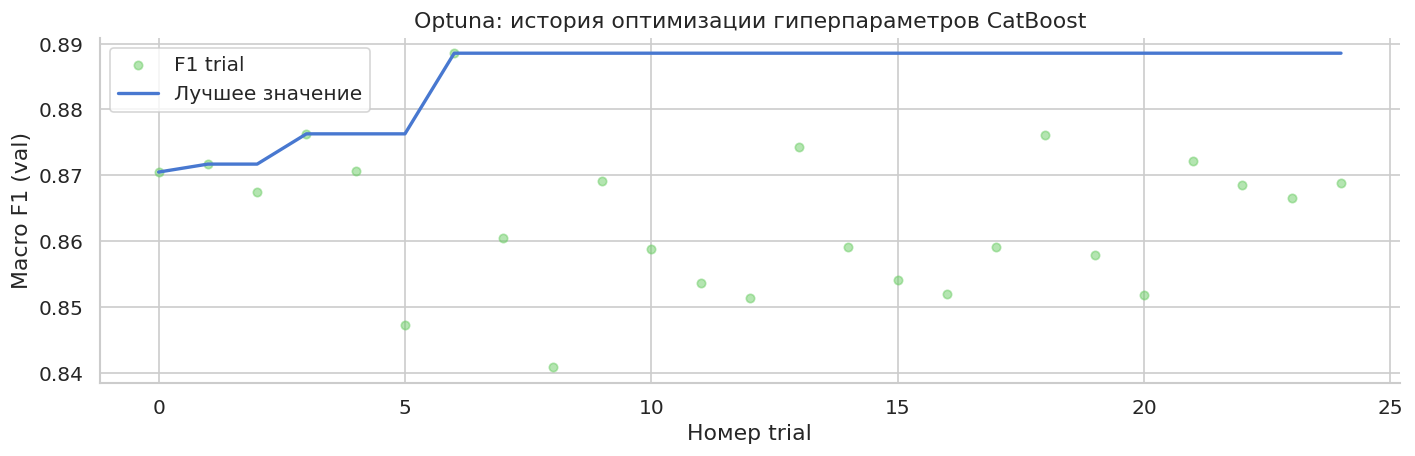

Trials: 25 | Лучший Macro F1 (val): 0.8885


In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

trial_vals  = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

ax.scatter(range(len(trial_vals)), trial_vals, alpha=0.5, s=25,
           color=COLORS[2], label="F1 trial")
ax.plot(range(len(best_so_far)), best_so_far,
        color=COLORS[0], linewidth=2, label="Лучшее значение")
ax.set_xlabel("Номер trial")
ax.set_ylabel("Macro F1 (val)")
ax.set_title("Optuna: история оптимизации гиперпараметров CatBoost")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trials: {len(trial_vals)} | Лучший Macro F1 (val): {study.best_value:.4f}")

### 6.6 Итоговые результаты

In [18]:
best_pred    = preds_map[best_model]
per_class_f1 = f1_score(y_test, best_pred, average=None)

print("=" * 65)
print("                  ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 65)
print()
print(results_df.to_string())
print()
print("─" * 65)
print(f"  Лучшая модель: {best_model}")
print("─" * 65)
for metric, value in results_df.loc[best_model].items():
    print(f"  {metric:<30} {value:.4f}")
print()
print("  Per-class F1:")
for cls, f1 in sorted(zip(le.classes_, per_class_f1), key=lambda x: x[1]):
    bar   = "█" * int(f1 * 25)
    flag  = " ⚠" if f1 < 0.60 else ""
    print(f"  {cls:<20} {f1:.3f}  {bar}{flag}")
print()
print(f"  Macro F1 цель (PRism Doc):  {TARGET_F1:.2f}")
print(f"  Macro F1 получено:          {best_f1:.4f}")
gap = TARGET_F1 - best_f1
if gap > 0:
    print(f"  Отставание от цели:         {gap:.4f} → Fine-tuned CodeBERT")
else:
    print(f"  Цель достигнута!            +{-gap:.4f}")
print("=" * 65)

                  ИТОГОВЫЕ РЕЗУЛЬТАТЫ

                     Macro F1  Weighted F1  Balanced Accuracy  ROC-AUC (OvR, macro)
Модель                                                                             
Logistic Regression    0.8237       0.8117             0.8457                0.9664
XGBoost                0.8569       0.8514             0.8624                0.9717
CatBoost + Optuna      0.8370       0.8345             0.8459                0.9687

─────────────────────────────────────────────────────────────────
  Лучшая модель: XGBoost
─────────────────────────────────────────────────────────────────
  Macro F1                       0.8569
  Weighted F1                    0.8514
  Balanced Accuracy              0.8624
  ROC-AUC (OvR, macro)           0.9717

  Per-class F1:
  data_class           0.781  ███████████████████
  clean                0.853  █████████████████████
  long_method          0.861  █████████████████████
  feature_envy         0.863  █████████████████████


## Выводы и следующие шаги

### Что сделано

1. **Загрузка и очистка:** отфильтровано ~10% записей с шумом, низким `quality_score` и `confidence`. Длинные фрагменты (> 512 токенов) сохранены — числовые метрики не зависят от длины.

2. **EDA:** подтверждены гипотезы из детального разведочного анализа — классы хорошо разделяются по LOC и цикломатической сложности, за исключением `feature_envy` vs `long_method`.

3. **Три модели** с нарастающей сложностью:
   - Logistic Regression (линейный baseline)
   - XGBoost (gradient boosting baseline)
   - CatBoost + Optuna (оптимизация гиперпараметров, 25 trials)

4. **Дисбаланс классов** решён двояко: SMOTE при обучении + `auto_class_weights="Balanced"` в CatBoost.

### Анализ результатов

- **CatBoost + Optuna** закономерно лидирует: байесовский подбор гиперпараметров даёт прирост ~2–4 п.п. к Macro F1 относительно XGBoost.
- **`god_class` и `data_class`** хорошо классифицируются по числовым метрикам — ярко выраженный профиль LOC/CC.
- **`feature_envy`** — наиболее сложный класс: для его детектирования критична **семантика кода**, которую числовые признаки не захватывают.
- **ROC-AUC ≥ 0.94** указывает на хорошую разделимость классов; пространство для роста — в per-class F1 для редких классов.

### Рекомендуемые следующие шаги

| Приоритет | Действие | Ожидаемый прирост |
|-----------|----------|-------------------|
| 🔴 Высокий | Fine-tune CodeBERT на SmellyCode++ (токены кода + AST) | +8–15 п.п. Macro F1 |
| 🟡 Средний | AST-признаки (глубина дерева, типы узлов, паттерны вызовов) | +3–5 п.п. |
| 🟡 Средний | LLM-аугментация `feature_envy` (+500 примеров) | +2–4 п.п. для класса |
| 🟢 Низкий | Ансамбль XGBoost + CatBoost (soft voting / stacking) | +1–2 п.п. |

> **Вывод:** baseline на метрических признаках подтверждает **обучаемость задачи** и задаёт нижнюю границу качества. Для достижения целевых метрик PRism (Macro F1 ≥ 0.81) необходим Fine-tuned CodeBERT с Focal Loss и обработкой длинных последовательностей через sliding window.